# ⚡ match_ddos_v2 — Notebook PARAMETRIZADO por subtipo

## Cómo usar este notebook

1. Cambia el valor de `SUBTIPO_DDOS` en la **CELDA 0** a uno de los 12 subtipos.
2. **Run All**. Se guardarán los 4 CSVs comunes en `MuestrasComunes/DDoS-{SUBTIPO}/`.
3. Repite para los otros subtipos (reiniciando el kernel entre ejecuciones).
4. Al final, ejecuta la **CELDA 6 (UNIÓN)** UNA SOLA VEZ tras tener los 12 subtipos hechos. Junta los CSVs comunes de cada herramienta en un único conjunto `DDoS` en `MuestrasComunes/DDoS/`.

## Cambios respecto a DoS

- **12 subtipos** en lugar de 4.
- **CIC: solo el primer CSV** que matchee el subtipo (la carpeta CIC pesa 13.7 GB total → cargar todos peta).
- **Tstat: fix de columnas finales** — se preservan todas las columnas originales (~138) al reconstruir `df_tstat_full`.
- **Etiqueta unificada `DDoS`** en la CELDA 5.4.
- **ICMP_Flood / ICMP_Fragmentation**: Tstat no procesa ICMP → para esos subtipos Tstat dará 0 flujos y por tanto Comunes 4 = 0. Es esperable.

In [1]:
# ============================================================
# CELDA 0 — IMPORTS Y PARÁMETROS GLOBALES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import gc
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ─── PARÁMETROS — CAMBIAR AQUÍ ENTRE EJECUCIONES ─────────────
SUBTIPO_DDOS = 'UDP_Fragmentation'   # Opciones (12): ver SUBTIPOS_VALIDOS abajo
OFFSET_HORAS = 1           # DDoS (asumido verano 2022 → UTC+2 CEST). Ajusta si los rangos no cuadran.
# ──────────────────────────────────────────────────────────────

SUBTIPOS_VALIDOS = [
    'ACK_Fragmentation', 'HTTP_Flood', 'ICMP_Flood', 'ICMP_Fragmentation',
    'PSHACK_Flood', 'SlowLoris', 'SYN_Flood', 'SynonymousIP_Flood',
    'TCP_Flood', 'UDP_Flood', 'UDP_Fragmentation', 'RSTFINFlood'
]

assert SUBTIPO_DDOS in SUBTIPOS_VALIDOS, \
    f"SUBTIPO_DDOS debe ser uno de {SUBTIPOS_VALIDOS}, no '{SUBTIPO_DDOS}'"

print(f'✓ Imports OK')
print(f'  pandas:       {pd.__version__}')
print(f'  numpy:        {np.__version__}')
print()
print(f'═══════════════════════════════════════════════')
print(f'  PROCESANDO SUBTIPO: DDoS-{SUBTIPO_DDOS}')
print(f'═══════════════════════════════════════════════')
print(f'  OFFSET_HORAS: {OFFSET_HORAS}h')

✓ Imports OK
  pandas:       2.2.0
  numpy:        1.26.4

═══════════════════════════════════════════════
  PROCESANDO SUBTIPO: DDoS-UDP_Fragmentation
═══════════════════════════════════════════════
  OFFSET_HORAS: 1h


# CICFlowMeter

In [2]:
# ============================================================
# CELDA 1.1 — CARGA DE CIC (SOLO PRIMER CSV del subtipo)
# ⚠ La carpeta CIC/DDoS pesa 13.7 GB → cargamos solo 1 archivo
# ============================================================

RUTA_CIC = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/DDoS')
print(f'Ruta CIC: {RUTA_CIC}')
print(f'Existe:   {RUTA_CIC.exists()}')
print()

csv_files = sorted(RUTA_CIC.glob(f'*{SUBTIPO_DDOS}*.csv'))
print(f'Patrón glob: *{SUBTIPO_DDOS}*.csv')
print(f'CSVs disponibles para {SUBTIPO_DDOS}: {len(csv_files)}')
for f in csv_files:
    print(f'  - {f.name}')

if not csv_files:
    raise FileNotFoundError(f'No se encontraron CSVs con patrón *{SUBTIPO_DDOS}*.csv en: {RUTA_CIC}')

# ⚠ Solo el primero para no petar memoria
csv_files = csv_files[:1]
print(f'\n→ Se carga SOLO el primero: {csv_files[0].name}')
print()

dfs = []
for f in csv_files:
    df_temp = pd.read_csv(f, low_memory=False)
    df_temp['archivo_origen'] = f.stem
    dfs.append(df_temp)
    print(f'  ✓ {f.name:50s} → {len(df_temp):>8,} filas')

df_cic = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

print()
print(f'Shape total CIC ({SUBTIPO_DDOS}): {df_cic.shape}')
print(f'NaNs totales:    {df_cic.isnull().sum().sum():,}')

Ruta CIC: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosCIC/DDoS
Existe:   True

Patrón glob: *UDP_Fragmentation*.csv
CSVs disponibles para UDP_Fragmentation: 13
  - DDoS-UDP_Fragmentation.pcap_Flow.csv
  - DDoS-UDP_Fragmentation1.pcap_Flow.csv
  - DDoS-UDP_Fragmentation10.pcap_Flow.csv
  - DDoS-UDP_Fragmentation11.pcap_Flow.csv
  - DDoS-UDP_Fragmentation12.pcap_Flow.csv
  - DDoS-UDP_Fragmentation2.pcap_Flow.csv
  - DDoS-UDP_Fragmentation3.pcap_Flow.csv
  - DDoS-UDP_Fragmentation4.pcap_Flow.csv
  - DDoS-UDP_Fragmentation5.pcap_Flow.csv
  - DDoS-UDP_Fragmentation6.pcap_Flow.csv
  - DDoS-UDP_Fragmentation7.pcap_Flow.csv
  - DDoS-UDP_Fragmentation8.pcap_Flow.csv
  - DDoS-UDP_Fragmentation9.pcap_Flow.csv

→ Se carga SOLO el primero: DDoS-UDP_Fragmentation.pcap_Flow.csv



  ✓ DDoS-UDP_Fragmentation.pcap_Flow.csv               →   10,205 filas

Shape total CIC (UDP_Fragmentation): (10205, 85)
NaNs totales:    5


In [3]:
# ============================================================
# CELDA 1.2 — LIMPIEZA Y NORMALIZACIÓN CIC
# ============================================================

df_cic['Timestamp'] = (
    df_cic['Timestamp'].astype(str)
    .str.replace(' p. m.', ' PM', regex=False)
    .str.replace(' a. m.', ' AM', regex=False)
    .str.strip()
)
df_cic['Timestamp'] = pd.to_datetime(
    df_cic['Timestamp'], format='%d/%m/%Y %I:%M:%S %p', errors='coerce'
)

nat_count = df_cic['Timestamp'].isna().sum()
print(f'NaT en Timestamp: {nat_count}')
if nat_count > 0:
    df_cic = df_cic.dropna(subset=['Timestamp']).reset_index(drop=True)

df_cic['Protocol']      = pd.to_numeric(df_cic['Protocol'],      errors='coerce').fillna(0).astype(int)
df_cic['Src Port']      = pd.to_numeric(df_cic['Src Port'],      errors='coerce').fillna(0).astype(int)
df_cic['Dst Port']      = pd.to_numeric(df_cic['Dst Port'],      errors='coerce').fillna(0).astype(int)
df_cic['Flow Duration'] = pd.to_numeric(df_cic['Flow Duration'], errors='coerce')

print(f'\nShape CIC limpio: {df_cic.shape}')
print(f'\nRango temporal CIC:')
print(f'  Min: {df_cic["Timestamp"].min()}')
print(f'  Max: {df_cic["Timestamp"].max()}')
print(f'\nDistribución por protocolo:')
print(df_cic['Protocol'].value_counts().to_string())

NaT en Timestamp: 0

Shape CIC limpio: (10205, 85)

Rango temporal CIC:
  Min: 2022-11-01 18:44:00
  Max: 2022-11-01 19:36:12

Distribución por protocolo:
Protocol
17    6629
6     3192
0      384


In [4]:
# ============================================================
# CELDA 1.3 — KEY BASE Y KEY EXACT CIC
# ============================================================

df_cic['time_sec']    = df_cic['Timestamp'].dt.floor('s')
df_cic['flow_dur_ms'] = (df_cic['Flow Duration'] / 1000).round().astype('Int64')

df_cic['key_base'] = list(zip(
    df_cic['Src IP'].astype(str),
    df_cic['Src Port'].astype(str),
    df_cic['Dst IP'].astype(str),
    df_cic['Dst Port'].astype(str),
    df_cic['Protocol'].astype(str),
    df_cic['time_sec'].astype(str)
))
df_cic['key_exact'] = list(zip(
    df_cic['Src IP'].astype(str),
    df_cic['Src Port'].astype(str),
    df_cic['Dst IP'].astype(str),
    df_cic['Dst Port'].astype(str),
    df_cic['Protocol'].astype(str),
    df_cic['time_sec'].astype(str),
    df_cic['flow_dur_ms'].astype(str)
))

print(f'Shape CIC: {df_cic.shape}')
print(f'Claves base únicas: {df_cic["key_base"].nunique():,}')

Shape CIC: (10205, 89)
Claves base únicas: 10,134


# NEMEA

In [5]:
# ============================================================
# CELDA 2.1 — CARGA DE NEMEA (filtrado por subtipo)
# ============================================================

RUTA_NEMEA = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/DDoS/DDoS')
print(f'Ruta Nemea: {RUTA_NEMEA}')
print(f'Existe:     {RUTA_NEMEA.exists()}')
print()

csv_files_nemea = sorted(RUTA_NEMEA.glob(f'*{SUBTIPO_DDOS}*.csv'))
print(f'Patrón glob: *{SUBTIPO_DDOS}*.csv')
print(f'CSVs Nemea encontrados: {len(csv_files_nemea)}')
for f in csv_files_nemea:
    print(f'  {f.name}')

if not csv_files_nemea:
    raise FileNotFoundError(f'No se encontraron CSVs Nemea con patrón *{SUBTIPO_DDOS}* en: {RUTA_NEMEA}')

col_etiqueta_nemea = pd.read_csv(csv_files_nemea[0], nrows=0).columns[-1]
print(f'\nColumna de etiqueta detectada: \'{col_etiqueta_nemea}\'')

dfs_nemea = []
for f in csv_files_nemea:
    df_temp = pd.read_csv(f, low_memory=False)
    df_temp['archivo_origen_nemea'] = f.stem
    dfs_nemea.append(df_temp)
    print(f'  ✓ {f.name:45s} → {len(df_temp):>8,} filas')

df_nemea = pd.concat(dfs_nemea, ignore_index=True)
del dfs_nemea
gc.collect()

print()
print(f'Shape Nemea total: {df_nemea.shape}')
print(f'NaNs:              {df_nemea.isnull().sum().sum():,}')

Ruta Nemea: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosNEMEA/DDoS/DDoS
Existe:     True

Patrón glob: *UDP_Fragmentation*.csv
CSVs Nemea encontrados: 1
  DDoS_UDP_Fragmentation_Nemea.csv

Columna de etiqueta detectada: 'LABEL'
  ✓ DDoS_UDP_Fragmentation_Nemea.csv              →  146,854 filas

Shape Nemea total: (146854, 206)
NaNs:              587,062


In [6]:
# ============================================================
# CELDA 2.2 — LIMPIEZA Y NORMALIZACIÓN NEMEA
# ============================================================

col_src_ip   = 'ipaddr SRC_IP'
col_dst_ip   = 'ipaddr DST_IP'
col_src_port = 'uint16 SRC_PORT'
col_dst_port = 'uint16 DST_PORT'
col_protocol = 'uint8 PROTOCOL'
col_t_first  = 'time TIME_FIRST'
col_t_last   = 'time TIME_LAST'

df_nemea[col_src_ip] = df_nemea[col_src_ip].astype(str).str.strip()
df_nemea[col_dst_ip] = df_nemea[col_dst_ip].astype(str).str.strip()

df_nemea['TIME_FIRST_limpio'] = df_nemea[col_t_first].astype(str).str.replace(',', '.', regex=False)
df_nemea['TIME_LAST_limpio']  = df_nemea[col_t_last].astype(str).str.replace(',', '.', regex=False)

df_nemea['TIME_FIRST_dt'] = pd.to_datetime(
    df_nemea['TIME_FIRST_limpio'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce'
)
df_nemea['TIME_LAST_dt'] = pd.to_datetime(
    df_nemea['TIME_LAST_limpio'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce'
)

df_nemea['TIME_FIRST_utc2'] = df_nemea['TIME_FIRST_dt'] + pd.Timedelta(hours=OFFSET_HORAS)
df_nemea['TIME_LAST_utc2']  = df_nemea['TIME_LAST_dt']  + pd.Timedelta(hours=OFFSET_HORAS)

df_nemea['flow_dur_us'] = (
    (df_nemea['TIME_LAST_dt'] - df_nemea['TIME_FIRST_dt']).dt.total_seconds() * 1_000_000
).round().astype('Int64')
df_nemea['flow_dur_ms'] = (df_nemea['flow_dur_us'] / 1000).round().astype('Int64')

print(f'Shape Nemea limpio: {df_nemea.shape}')
print(f'\nRango temporal Nemea (UTC+{OFFSET_HORAS}):')
print(f"  Min: {df_nemea['TIME_FIRST_utc2'].min()}")
print(f"  Max: {df_nemea['TIME_FIRST_utc2'].max()}")
print(f'\nRango CIC (comprobar alineamiento):')
print(f'  Min: {df_cic["Timestamp"].min()}')
print(f'  Max: {df_cic["Timestamp"].max()}')

Shape Nemea limpio: (146854, 214)

Rango temporal Nemea (UTC+1):
  Min: 2022-11-01 18:44:00.173997
  Max: 2022-11-03 14:52:00.177753

Rango CIC (comprobar alineamiento):
  Min: 2022-11-01 18:44:00
  Max: 2022-11-01 19:36:12


In [7]:
# ============================================================
# CELDA 2.3 — KEY BASE Y MATCHING CIC ∩ NEMEA
# ============================================================

df_nemea['time_sec'] = df_nemea['TIME_FIRST_utc2'].dt.floor('s')

df_nemea['key_base_dir'] = list(zip(
    df_nemea[col_src_ip].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea[col_dst_ip].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea[col_protocol].astype(str), df_nemea['time_sec'].astype(str)
))
df_nemea['key_base_inv'] = list(zip(
    df_nemea[col_dst_ip].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea[col_src_ip].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea[col_protocol].astype(str), df_nemea['time_sec'].astype(str)
))
df_nemea['key_exact_dir'] = list(zip(
    df_nemea[col_src_ip].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea[col_dst_ip].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea[col_protocol].astype(str), df_nemea['time_sec'].astype(str),
    df_nemea['flow_dur_ms'].astype(str)
))
df_nemea['key_exact_inv'] = list(zip(
    df_nemea[col_dst_ip].astype(str), df_nemea[col_dst_port].astype(str),
    df_nemea[col_src_ip].astype(str), df_nemea[col_src_port].astype(str),
    df_nemea[col_protocol].astype(str), df_nemea['time_sec'].astype(str),
    df_nemea['flow_dur_ms'].astype(str)
))

cic_keys_base  = set(df_cic['key_base'])
cic_keys_exact = set(df_cic['key_exact'])

nemea_base_dir  = set(df_nemea['key_base_dir'])
nemea_base_inv  = set(df_nemea['key_base_inv'])
nemea_exact_dir = set(df_nemea['key_exact_dir'])
nemea_exact_inv = set(df_nemea['key_exact_inv'])

match_nemea_base  = cic_keys_base  & (nemea_base_dir  | nemea_base_inv)
match_nemea_exact = cic_keys_exact & (nemea_exact_dir | nemea_exact_inv)

print('=' * 60)
print(f'MATCHING CIC ∩ NEMEA — DDoS-{SUBTIPO_DDOS}')
print('=' * 60)
print(f'  CIC total flujos:            {len(df_cic):,}')
print(f'  Nemea total flujos:          {len(df_nemea):,}')
print()
print(f'  Match BASE (sin duración):   {len(match_nemea_base):,}  ({round(len(match_nemea_base)/max(len(cic_keys_base),1)*100,2)}%)')
print(f'  Match EXACTO (con dur. ms):  {len(match_nemea_exact):,}  ({round(len(match_nemea_exact)/max(len(cic_keys_base),1)*100,2)}%)')

del nemea_base_dir, nemea_base_inv, nemea_exact_dir, nemea_exact_inv
df_nemea = df_nemea.drop(columns=['key_exact_dir', 'key_exact_inv'])
gc.collect()

MATCHING CIC ∩ NEMEA — DDoS-UDP_Fragmentation
  CIC total flujos:            10,205
  Nemea total flujos:          146,854

  Match BASE (sin duración):   7,650  (75.49%)
  Match EXACTO (con dur. ms):  6,398  (63.13%)


25

# TSTAT

In [8]:
# ============================================================
# CELDA 3.1 — CARGA DE TSTAT (filtrado por subtipo)
# ⚠ Tstat solo procesa TCP/UDP → ICMP_* dará 0 flujos
# ============================================================

RUTA_TSTAT = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/DDoS')
print(f'Ruta Tstat: {RUTA_TSTAT}')
print(f'Existe:     {RUTA_TSTAT.exists()}')
print()

csv_files_tstat = sorted(RUTA_TSTAT.glob(f'*{SUBTIPO_DDOS}*.csv'))
print(f'Patrón glob: *{SUBTIPO_DDOS}*.csv')
print(f'CSVs Tstat encontrados: {len(csv_files_tstat)}')
for f in csv_files_tstat:
    print(f'  {f.name}')

if not csv_files_tstat:
    raise FileNotFoundError(f'No se encontraron CSVs Tstat con patrón *{SUBTIPO_DDOS}* en: {RUTA_TSTAT}')

dfs_tstat = []
for f in csv_files_tstat:
    df_temp = pd.read_csv(f, low_memory=False)
    dfs_tstat.append(df_temp)
    print(f'  ✓ {f.name:40s} → {len(df_temp):>8,} filas')

df_tstat = pd.concat(dfs_tstat, ignore_index=True)
del dfs_tstat
gc.collect()

print()
print(f'Shape total Tstat: {df_tstat.shape}')
if 'protocolo' in df_tstat.columns:
    print(f'\nDistribución por protocolo:')
    print(df_tstat['protocolo'].value_counts().to_string())
else:
    print('  ⚠ Sin columna "protocolo" — Tstat vacío para este subtipo')

Ruta Tstat: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTstat/CSV/DDoS
Existe:     True

Patrón glob: *UDP_Fragmentation*.csv
CSVs Tstat encontrados: 1
  DDoS-UDP_Fragmentation.csv
  ✓ DDoS-UDP_Fragmentation.csv               →    7,926 filas

Shape total Tstat: (7926, 138)

Distribución por protocolo:
protocolo
UDP    6790
TCP    1136


In [9]:
# ============================================================
# CELDA 3.2 — LIMPIEZA Y SEPARACIÓN TCP/UDP TSTAT
# ============================================================

if 'protocolo' in df_tstat.columns and len(df_tstat) > 0:
    df_tcp_tstat = df_tstat[df_tstat['protocolo'] == 'TCP'].copy()
    df_udp_tstat = df_tstat[df_tstat['protocolo'] == 'UDP'].copy()
else:
    df_tcp_tstat = pd.DataFrame()
    df_udp_tstat = pd.DataFrame()

print(f'TCP total: {len(df_tcp_tstat):,}  | UDP total: {len(df_udp_tstat):,}')
print()

# ── TCP
if len(df_tcp_tstat) > 0:
    df_tcp_tstat['first'] = pd.to_numeric(df_tcp_tstat['first'], errors='coerce')
    n_antes = len(df_tcp_tstat)
    df_tcp_tstat = df_tcp_tstat[df_tcp_tstat['first'] > 0].copy()
    print(f'TCP válidos (first>0): {len(df_tcp_tstat):,}  (eliminados: {n_antes-len(df_tcp_tstat):,})')

    df_tcp_tstat['first_dt']    = pd.to_datetime(df_tcp_tstat['first'], unit='ms', errors='coerce')
    df_tcp_tstat['first_utc2']  = df_tcp_tstat['first_dt'] + pd.Timedelta(hours=OFFSET_HORAS)
    df_tcp_tstat['flow_dur_ms'] = df_tcp_tstat['durat'].round().astype('Int64')
    df_tcp_tstat['flow_dur_us'] = (df_tcp_tstat['durat'] * 1000).round().astype('Int64')
    df_tcp_tstat['proto_num']   = 6

# ── UDP
if len(df_udp_tstat) > 0:
    df_udp_tstat['c_first_abs'] = pd.to_numeric(df_udp_tstat['c_first_abs'], errors='coerce')
    n_antes = len(df_udp_tstat)
    df_udp_tstat = df_udp_tstat[df_udp_tstat['c_first_abs'] > 0].copy()
    print(f'UDP válidos (c_first_abs>0): {len(df_udp_tstat):,}  (eliminados: {n_antes-len(df_udp_tstat):,})')

    df_udp_tstat['first_dt']    = pd.to_datetime(df_udp_tstat['c_first_abs'], unit='ms', errors='coerce')
    df_udp_tstat['first_utc2']  = df_udp_tstat['first_dt'] + pd.Timedelta(hours=OFFSET_HORAS)
    df_udp_tstat['c_durat']     = pd.to_numeric(df_udp_tstat['c_durat'], errors='coerce').fillna(0)
    df_udp_tstat['s_durat']     = pd.to_numeric(df_udp_tstat['s_durat'], errors='coerce').fillna(0)
    df_udp_tstat['flow_dur_ms'] = df_udp_tstat[['c_durat','s_durat']].max(axis=1).round().astype('Int64')
    df_udp_tstat['flow_dur_us'] = (df_udp_tstat['flow_dur_ms'] * 1000).round().astype('Int64')
    df_udp_tstat['proto_num']   = 17

del df_tstat
gc.collect()

TCP total: 1,136  | UDP total: 6,790

TCP válidos (first>0): 1,136  (eliminados: 0)
UDP válidos (c_first_abs>0): 6,790  (eliminados: 0)


0

In [10]:
# ============================================================
# CELDA 3.3 — BASE UNIFICADA TSTAT
# ============================================================

cols_base_tstat = ['c_ip','c_port','s_ip','s_port','proto_num',
                   'first_utc2','flow_dur_us','flow_dur_ms']

df_tstat_base = pd.concat([
    df_tcp_tstat[cols_base_tstat] if len(df_tcp_tstat) > 0 else pd.DataFrame(columns=cols_base_tstat),
    df_udp_tstat[cols_base_tstat] if len(df_udp_tstat) > 0 else pd.DataFrame(columns=cols_base_tstat),
], ignore_index=True)

if len(df_tstat_base) > 0:
    df_tstat_base['time_sec'] = df_tstat_base['first_utc2'].dt.floor('s')
else:
    df_tstat_base['time_sec'] = pd.Series(dtype='datetime64[ns]')

print(f'Shape Tstat base: {df_tstat_base.shape}')
if len(df_tstat_base) > 0:
    print(f"  TCP: {(df_tstat_base['proto_num']==6).sum():,}")
    print(f"  UDP: {(df_tstat_base['proto_num']==17).sum():,}")
    print(f'\nRango temporal Tstat (UTC+{OFFSET_HORAS}):')
    print(f"  Min: {df_tstat_base['time_sec'].min()}")
    print(f"  Max: {df_tstat_base['time_sec'].max()}")
else:
    print('  ⚠ Tstat vacío para este subtipo (probablemente ICMP)')

Shape Tstat base: (7926, 9)
  TCP: 1,136
  UDP: 6,790

Rango temporal Tstat (UTC+1):
  Min: 2022-11-01 18:44:00
  Max: 2022-11-01 19:36:12


In [11]:
# ============================================================
# CELDA 3.4 — KEY BASE Y MATCHING CIC ∩ TSTAT
# NOTA: NO se borran df_tcp_tstat ni df_udp_tstat (los usamos al final
# para reconstruir df_tstat_full con todas las columnas).
# ============================================================

if len(df_tstat_base) > 0:
    df_tstat_base['key_base_dir'] = list(zip(
        df_tstat_base['c_ip'].astype(str), df_tstat_base['c_port'].astype(str),
        df_tstat_base['s_ip'].astype(str), df_tstat_base['s_port'].astype(str),
        df_tstat_base['proto_num'].astype(str), df_tstat_base['time_sec'].astype(str)
    ))
    df_tstat_base['key_base_inv'] = list(zip(
        df_tstat_base['s_ip'].astype(str), df_tstat_base['s_port'].astype(str),
        df_tstat_base['c_ip'].astype(str), df_tstat_base['c_port'].astype(str),
        df_tstat_base['proto_num'].astype(str), df_tstat_base['time_sec'].astype(str)
    ))

    df_tstat_dur = df_tstat_base[df_tstat_base['flow_dur_ms'] > 0].copy()
    df_tstat_dur['key_exact_dir'] = list(zip(
        df_tstat_dur['c_ip'].astype(str), df_tstat_dur['c_port'].astype(str),
        df_tstat_dur['s_ip'].astype(str), df_tstat_dur['s_port'].astype(str),
        df_tstat_dur['proto_num'].astype(str), df_tstat_dur['time_sec'].astype(str),
        df_tstat_dur['flow_dur_ms'].astype(str)
    ))
    df_tstat_dur['key_exact_inv'] = list(zip(
        df_tstat_dur['s_ip'].astype(str), df_tstat_dur['s_port'].astype(str),
        df_tstat_dur['c_ip'].astype(str), df_tstat_dur['c_port'].astype(str),
        df_tstat_dur['proto_num'].astype(str), df_tstat_dur['time_sec'].astype(str),
        df_tstat_dur['flow_dur_ms'].astype(str)
    ))

    tstat_base_keys  = set(df_tstat_base['key_base_dir']) | set(df_tstat_base['key_base_inv'])
    tstat_exact_keys = set(df_tstat_dur['key_exact_dir']) | set(df_tstat_dur['key_exact_inv'])
else:
    df_tstat_base['key_base_dir'] = pd.Series(dtype=object)
    df_tstat_base['key_base_inv'] = pd.Series(dtype=object)
    tstat_base_keys  = set()
    tstat_exact_keys = set()
    df_tstat_dur = pd.DataFrame()

match_tstat_base  = cic_keys_base  & tstat_base_keys
match_tstat_exact = cic_keys_exact & tstat_exact_keys

print('=' * 60)
print(f'MATCHING CIC ∩ TSTAT — DDoS-{SUBTIPO_DDOS}')
print('=' * 60)
print(f'  Tstat total flujos:          {len(df_tstat_base):,}')
print()
print(f'  Match BASE (sin duración):   {len(match_tstat_base):,}  ({round(len(match_tstat_base)/max(len(cic_keys_base),1)*100,2)}%)')
print(f'  Match EXACTO (con dur. ms):  {len(match_tstat_exact):,}  ({round(len(match_tstat_exact)/max(len(cic_keys_base),1)*100,2)}%)')

# Ojo: NO borramos df_tcp_tstat ni df_udp_tstat (los necesitamos en la celda final)
del tstat_base_keys, tstat_exact_keys, df_tstat_dur
gc.collect()

MATCHING CIC ∩ TSTAT — DDoS-UDP_Fragmentation
  Tstat total flujos:          7,926

  Match BASE (sin duración):   6,633  (65.45%)
  Match EXACTO (con dur. ms):  809  (7.98%)


0

# TSHARK

In [12]:
# ============================================================
# CELDA 4.1 — CARGA DE TSHARK (filtrado por subtipo, SIN sampling)
# ============================================================

RUTA_TSHARK = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/DDoS')
print(f'Ruta Tshark: {RUTA_TSHARK}')
print(f'Existe:      {RUTA_TSHARK.exists()}')
print()

csv_files_tshark = sorted(RUTA_TSHARK.glob(f'*{SUBTIPO_DDOS}*.csv'))
print(f'Patrón glob: *{SUBTIPO_DDOS}*.csv')
print(f'CSVs encontrados: {len(csv_files_tshark)}')
for f in csv_files_tshark:
    print(f'  {f.name}')
print()

if not csv_files_tshark:
    raise FileNotFoundError(f'No se encontraron CSVs Tshark con patrón *{SUBTIPO_DDOS}* en: {RUTA_TSHARK}')

dfs_tshark = []
for f in csv_files_tshark:
    df_temp = pd.read_csv(f, low_memory=False)
    df_temp['archivo_origen'] = f.stem
    dfs_tshark.append(df_temp)
    print(f'  ✓ {f.name:40s} → {len(df_temp):>8,} filas')

df_tshark = pd.concat(dfs_tshark, ignore_index=True)
del dfs_tshark
gc.collect()

print()
print(f'Shape Tshark: {df_tshark.shape}')

Ruta Tshark: /home/miguel/Escritorio/TFM/TFM_Miguel/ArchivosTshark_2/Csv/DDoS
Existe:      True

Patrón glob: *UDP_Fragmentation*.csv
CSVs encontrados: 1
  DDoS-UDP_Fragmentation.csv

  ✓ DDoS-UDP_Fragmentation.csv               →    7,885 filas

Shape Tshark: (7885, 65)


In [13]:
# ============================================================
# CELDA 4.2 — LIMPIEZA Y NORMALIZACIÓN TSHARK
# ============================================================

df_tshark['start_dt']    = pd.to_datetime(df_tshark['start_epoch'], unit='s', errors='coerce')
df_tshark['start_utc2']  = df_tshark['start_dt'] + pd.Timedelta(hours=OFFSET_HORAS)
df_tshark['flow_dur_us'] = (df_tshark['flow_duration_s'] * 1_000_000).round().astype('Int64')
df_tshark['flow_dur_ms'] = (df_tshark['flow_duration_s'] * 1_000).round().astype('Int64')
df_tshark['proto_num']   = pd.to_numeric(df_tshark['proto_num'], errors='coerce').fillna(0).astype(int)

n_antes = len(df_tshark)
df_tshark = df_tshark.dropna(subset=['src_ip','dst_ip']).reset_index(drop=True)
print(f'Filas eliminadas sin IP: {n_antes - len(df_tshark):,}')

print(f'\nShape Tshark limpio: {df_tshark.shape}')
print(f'\nRango temporal Tshark (UTC+{OFFSET_HORAS}):')
print(f"  Min: {df_tshark['start_utc2'].min()}")
print(f"  Max: {df_tshark['start_utc2'].max()}")

Filas eliminadas sin IP: 0

Shape Tshark limpio: (7885, 69)

Rango temporal Tshark (UTC+1):
  Min: 2022-11-01 18:44:00.173996925
  Max: 2022-11-01 19:36:12.642544031


In [14]:
# ============================================================
# CELDA 4.3 — KEY BASE Y MATCHING CIC ∩ TSHARK
# ============================================================

df_tshark['time_sec'] = df_tshark['start_utc2'].dt.floor('s')

df_tshark['key_base_dir'] = list(zip(
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str)
))
df_tshark['key_base_inv'] = list(zip(
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str)
))
df_tshark['key_exact_dir'] = list(zip(
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str),
    df_tshark['flow_dur_ms'].astype(str)
))
df_tshark['key_exact_inv'] = list(zip(
    df_tshark['dst_ip'].astype(str), df_tshark['dst_port'].astype(str),
    df_tshark['src_ip'].astype(str), df_tshark['src_port'].astype(str),
    df_tshark['proto_num'].astype(str), df_tshark['time_sec'].astype(str),
    df_tshark['flow_dur_ms'].astype(str)
))

tshark_base_keys  = set(df_tshark['key_base_dir']) | set(df_tshark['key_base_inv'])
tshark_exact_keys = set(df_tshark['key_exact_dir']) | set(df_tshark['key_exact_inv'])

match_tshark_base  = cic_keys_base  & tshark_base_keys
match_tshark_exact = cic_keys_exact & tshark_exact_keys

print('=' * 60)
print(f'MATCHING CIC ∩ TSHARK — DDoS-{SUBTIPO_DDOS}')
print('=' * 60)
print(f'  Tshark total flujos:         {len(df_tshark):,}')
print()
print(f'  Match BASE (sin duración):   {len(match_tshark_base):,}  ({round(len(match_tshark_base)/max(len(cic_keys_base),1)*100,2)}%)')
print(f'  Match EXACTO (con dur. ms):  {len(match_tshark_exact):,}  ({round(len(match_tshark_exact)/max(len(cic_keys_base),1)*100,2)}%)')

del tshark_base_keys, tshark_exact_keys
df_tshark = df_tshark.drop(columns=['key_exact_dir', 'key_exact_inv'])
gc.collect()

MATCHING CIC ∩ TSHARK — DDoS-UDP_Fragmentation
  Tshark total flujos:         7,885

  Match BASE (sin duración):   7,164  (70.69%)
  Match EXACTO (con dur. ms):  4,511  (44.51%)


25

# Intersección las 4

In [15]:
# ============================================================
# CELDA 5.1 — INTERSECCIÓN 4 HERRAMIENTAS
# ============================================================

base_4  = match_nemea_base  & match_tstat_base  & match_tshark_base
exact_4 = match_nemea_exact & match_tstat_exact & match_tshark_exact

print('=' * 60)
print(f'INTERSECCIÓN 4 HERRAMIENTAS — DDoS-{SUBTIPO_DDOS}')
print('=' * 60)
print(f'  CIC total claves:              {len(cic_keys_base):>8,}')
print(f'  CIC ∩ Nemea  (base):           {len(match_nemea_base):>8,}  ({round(len(match_nemea_base)/max(len(cic_keys_base),1)*100,2)}%)')
print(f'  CIC ∩ Tstat  (base):           {len(match_tstat_base):>8,}  ({round(len(match_tstat_base)/max(len(cic_keys_base),1)*100,2)}%)')
print(f'  CIC ∩ Tshark (base):           {len(match_tshark_base):>8,}  ({round(len(match_tshark_base)/max(len(cic_keys_base),1)*100,2)}%)')
print()
print(f'  COMUNES 4 (base, sin dur.):    {len(base_4):>8,}  ({round(len(base_4)/max(len(cic_keys_base),1)*100,2)}%)')
print(f'  COMUNES 4 (exacto, con dur.):  {len(exact_4):>8,}  ({round(len(exact_4)/max(len(cic_keys_base),1)*100,2)}%)')
print()
print(f'  Flujos extra al quitar dur.:   {len(base_4)-len(exact_4):>8,}')

INTERSECCIÓN 4 HERRAMIENTAS — DDoS-UDP_Fragmentation
  CIC total claves:                10,134
  CIC ∩ Nemea  (base):              7,650  (75.49%)
  CIC ∩ Tstat  (base):              6,633  (65.45%)
  CIC ∩ Tshark (base):              7,164  (70.69%)

  COMUNES 4 (base, sin dur.):       6,391  (63.06%)
  COMUNES 4 (exacto, con dur.):       628  (6.2%)

  Flujos extra al quitar dur.:      5,763


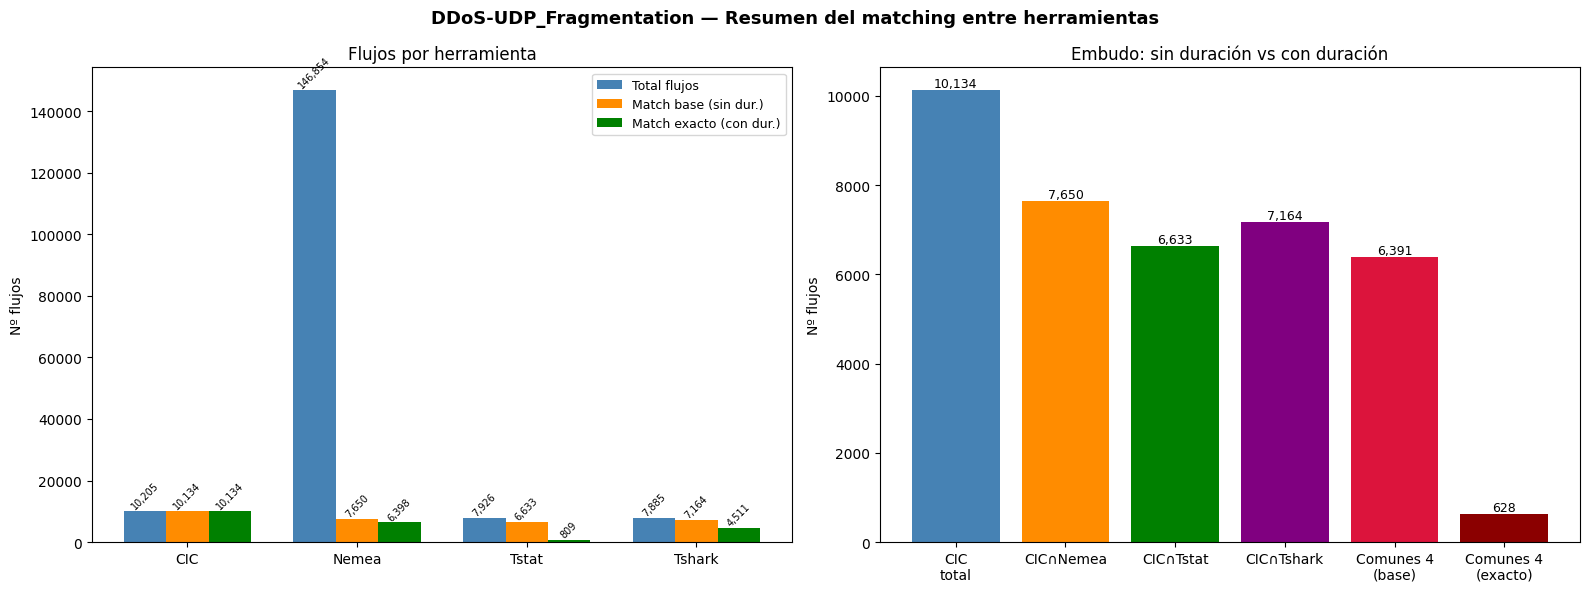

In [16]:
# ============================================================
# CELDA 5.2 — GRÁFICA RESUMEN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'DDoS-{SUBTIPO_DDOS} — Resumen del matching entre herramientas',
             fontsize=13, fontweight='bold')

ax1 = axes[0]
herramientas = ['CIC', 'Nemea', 'Tstat', 'Tshark']
totales = [len(df_cic), len(df_nemea), len(df_tstat_base), len(df_tshark)]
base    = [len(cic_keys_base), len(match_nemea_base), len(match_tstat_base), len(match_tshark_base)]
exactos = [len(cic_keys_base), len(match_nemea_exact), len(match_tstat_exact), len(match_tshark_exact)]

x, width = np.arange(len(herramientas)), 0.25
b1 = ax1.bar(x - width, totales, width, label='Total flujos',            color='steelblue')
b2 = ax1.bar(x,         base,    width, label='Match base (sin dur.)',   color='darkorange')
b3 = ax1.bar(x + width, exactos, width, label='Match exacto (con dur.)', color='green')
ax1.set_title('Flujos por herramienta')
ax1.set_ylabel('Nº flujos')
ax1.set_xticks(x)
ax1.set_xticklabels(herramientas)
ax1.legend(fontsize=9)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h,
                 f'{h:,}', ha='center', va='bottom', fontsize=7, rotation=45)

ax2 = axes[1]
labels2 = ['CIC\ntotal','CIC∩Nemea','CIC∩Tstat','CIC∩Tshark',
           'Comunes 4\n(base)','Comunes 4\n(exacto)']
values2 = [len(cic_keys_base), len(match_nemea_base), len(match_tstat_base),
           len(match_tshark_base), len(base_4), len(exact_4)]
colors2 = ['steelblue','darkorange','green','purple','crimson','darkred']
bars2 = ax2.bar(labels2, values2, color=colors2)
ax2.set_title('Embudo: sin duración vs con duración')
ax2.set_ylabel('Nº flujos')
for bar, val in zip(bars2, values2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# CELDA 5.3 — EXTRACCIÓN FINAL: 4 CSVs CON TODAS LAS COLUMNAS
# 🛠 Tstat: se reconstruye df_tstat_full (TCP+UDP) para conservar las ~138 cols
# ============================================================

OUTPUT_DIR = Path(f'/home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DDoS-{SUBTIPO_DDOS}')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COLS_AUX_CIC = ['archivo_origen','time_sec','flow_dur_ms','key_base','key_exact']

COLS_AUX_NEMEA = ['TIME_FIRST_limpio','TIME_LAST_limpio',
                  'TIME_FIRST_dt','TIME_LAST_dt',
                  'TIME_FIRST_utc2','TIME_LAST_utc2',
                  'time_sec','flow_dur_us','flow_dur_ms',
                  'key_base_dir','key_base_inv','_key']

COLS_AUX_TSTAT = ['first_utc2','first_dt','flow_dur_us','flow_dur_ms',
                  'time_sec','key_base_dir','key_base_inv',
                  '_key','proto_num']

COLS_AUX_TSHARK = ['start_dt','start_utc2','flow_dur_us','flow_dur_ms',
                   'time_sec','key_base_dir','key_base_inv',
                   'proto_num','archivo_origen','_key']

# ── NEMEA: asignar _key según base_4
df_nemea['_key'] = None
df_nemea.loc[df_nemea['key_base_dir'].isin(base_4), '_key'] = \
    df_nemea.loc[df_nemea['key_base_dir'].isin(base_4), 'key_base_dir']
df_nemea.loc[df_nemea['key_base_inv'].isin(base_4) & df_nemea['_key'].isna(), '_key'] = \
    df_nemea.loc[df_nemea['key_base_inv'].isin(base_4) & df_nemea['_key'].isna(), 'key_base_inv']

# ── TSTAT: asignar _key según base_4 sobre df_tstat_base
df_tstat_base['_key'] = None
if len(df_tstat_base) > 0:
    df_tstat_base.loc[df_tstat_base['key_base_dir'].isin(base_4), '_key'] = \
        df_tstat_base.loc[df_tstat_base['key_base_dir'].isin(base_4), 'key_base_dir']
    df_tstat_base.loc[df_tstat_base['key_base_inv'].isin(base_4) & df_tstat_base['_key'].isna(), '_key'] = \
        df_tstat_base.loc[df_tstat_base['key_base_inv'].isin(base_4) & df_tstat_base['_key'].isna(), 'key_base_inv']

# ── TSHARK: asignar _key según base_4
df_tshark['_key'] = None
df_tshark.loc[df_tshark['key_base_dir'].isin(base_4), '_key'] = \
    df_tshark.loc[df_tshark['key_base_dir'].isin(base_4), 'key_base_dir']
df_tshark.loc[df_tshark['key_base_inv'].isin(base_4) & df_tshark['_key'].isna(), '_key'] = \
    df_tshark.loc[df_tshark['key_base_inv'].isin(base_4) & df_tshark['_key'].isna(), 'key_base_inv']

# Calcular intersección real de claves presentes en las 4 herramientas
claves_nemea  = set(df_nemea[df_nemea['_key'].notna()]['_key'])
claves_tstat  = set(df_tstat_base[df_tstat_base['_key'].notna()]['_key']) if len(df_tstat_base) > 0 else set()
claves_tshark = set(df_tshark[df_tshark['_key'].notna()]['_key'])
claves_cic    = set(df_cic['key_base'])
claves_finales = claves_nemea & claves_tstat & claves_tshark & claves_cic

print(f'Claves comunes reales (en las 4): {len(claves_finales):,}')
print()

# ── NEMEA
df_nemea_4 = df_nemea[df_nemea['_key'].isin(claves_finales)].drop_duplicates(subset=['_key']).copy()
df_nemea_4 = df_nemea_4.drop(columns=COLS_AUX_NEMEA, errors='ignore').reset_index(drop=True)
print(f'Nemea:  {len(df_nemea_4):,} filas')

# ── TSTAT — 🛠 reconstrucción con todas las columnas originales
if len(df_tstat_base) > 0 and (len(df_tcp_tstat) > 0 or len(df_udp_tstat) > 0):
    df_tstat_full = pd.concat([df_tcp_tstat, df_udp_tstat], ignore_index=True)
    df_tstat_full['_key'] = df_tstat_base['_key'].values
    df_tstat_4 = df_tstat_full[df_tstat_full['_key'].isin(claves_finales)].drop_duplicates(subset=['_key']).copy()
    df_tstat_4 = df_tstat_4.drop(columns=COLS_AUX_TSTAT, errors='ignore').reset_index(drop=True)
else:
    df_tstat_4 = pd.DataFrame()
print(f'Tstat:  {len(df_tstat_4):,} filas')

# ── TSHARK
df_tshark_4 = df_tshark[df_tshark['_key'].isin(claves_finales)].drop_duplicates(subset=['_key']).copy()
df_tshark_4 = df_tshark_4.drop(columns=COLS_AUX_TSHARK, errors='ignore').reset_index(drop=True)
print(f'Tshark: {len(df_tshark_4):,} filas')

# ── CIC
df_cic_4 = df_cic[df_cic['key_base'].isin(claves_finales)].drop_duplicates(subset=['key_base']).copy()
df_cic_4 = df_cic_4.drop(columns=COLS_AUX_CIC, errors='ignore').reset_index(drop=True)
print(f'CIC:    {len(df_cic_4):,} filas')

# Guardar
df_cic_4.to_csv(   OUTPUT_DIR / 'CIC_comunes.csv',    index=False)
df_nemea_4.to_csv( OUTPUT_DIR / 'Nemea_comunes.csv',  index=False)
df_tshark_4.to_csv(OUTPUT_DIR / 'Tshark_comunes.csv', index=False)
df_tstat_4.to_csv( OUTPUT_DIR / 'Tstat_comunes.csv',  index=False)

print()
print('=' * 60)
print(f'RESULTADO FINAL — DDoS-{SUBTIPO_DDOS}')
print('=' * 60)
print(f'  CIC:    {len(df_cic_4):>6,} filas x {df_cic_4.shape[1]:>3} columnas')
print(f'  Nemea:  {len(df_nemea_4):>6,} filas x {df_nemea_4.shape[1]:>3} columnas')
print(f'  Tstat:  {len(df_tstat_4):>6,} filas x {df_tstat_4.shape[1]:>3} columnas')
print(f'  Tshark: {len(df_tshark_4):>6,} filas x {df_tshark_4.shape[1]:>3} columnas')
print(f'\n  Guardados en: {OUTPUT_DIR}')

if len(df_cic_4) == len(df_nemea_4) == len(df_tstat_4) == len(df_tshark_4):
    print(f'\n  ✓ VERIFICACIÓN CORRECTA — los 4 CSVs tienen {len(df_cic_4):,} flujos')
else:
    print(f'\n  ✗ Algún CSV no coincide → revisar')

Claves comunes reales (en las 4): 6,391

Nemea:  6,391 filas
Tstat:  6,391 filas
Tshark: 6,391 filas
CIC:    6,391 filas

RESULTADO FINAL — DDoS-UDP_Fragmentation
  CIC:     6,391 filas x  84 columnas
  Nemea:   6,391 filas x 206 columnas
  Tstat:   6,391 filas x 138 columnas
  Tshark:  6,391 filas x  63 columnas

  Guardados en: /home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DDoS-UDP_Fragmentation

  ✓ VERIFICACIÓN CORRECTA — los 4 CSVs tienen 6,391 flujos


In [18]:
# ============================================================
# CELDA 5.4 — ESTANDARIZAR ETIQUETA A 'DDoS' EN LOS 4 CSVs
# ============================================================

LABEL_MAP = {
    'CIC':    (df_cic_4,    'Label'),
    'Nemea':  (df_nemea_4,  col_etiqueta_nemea),
    'Tshark': (df_tshark_4, 'category'),
    'Tstat':  (df_tstat_4,  'etiqueta'),
}

for nombre, (df, col) in LABEL_MAP.items():
    if len(df) == 0:
        print(f'  ⚠ {nombre}: DataFrame vacío, no se actualiza etiqueta')
        continue
    if col in df.columns:
        antes = df[col].value_counts().to_dict()
        df[col] = 'DDoS'
        print(f'{nombre:8s} | {col:20s} → antes: {antes}')
        print(f'{"":8s} |                       → ahora: {df[col].unique().tolist()}')
    else:
        print(f'  ⚠ {nombre}: columna \'{col}\' no encontrada')

# Sobreescribir con etiquetas actualizadas
df_cic_4.to_csv(   OUTPUT_DIR / 'CIC_comunes.csv',    index=False)
df_nemea_4.to_csv( OUTPUT_DIR / 'Nemea_comunes.csv',  index=False)
df_tshark_4.to_csv(OUTPUT_DIR / 'Tshark_comunes.csv', index=False)
df_tstat_4.to_csv( OUTPUT_DIR / 'Tstat_comunes.csv',  index=False)

print()
print(f'✓ Etiquetas actualizadas y CSVs guardados en {OUTPUT_DIR}')
print(f'\n⏭  Siguiente paso: cambia SUBTIPO_DDOS en CELDA 0,')
print(f'   reinicia kernel (Restart) y vuelve a ejecutar Run All.')

CIC      | Label                → antes: {'DDoS-UDP_Fragmentation': 6391}
         |                       → ahora: ['DDoS']
Nemea    | LABEL                → antes: {'DDoS': 6391}
         |                       → ahora: ['DDoS']
Tshark   | category             → antes: {'DDoS-UDP_Fragmentation': 6391}
         |                       → ahora: ['DDoS']
Tstat    | etiqueta             → antes: {'DDoS-UDP_Fragmentation': 6391}
         |                       → ahora: ['DDoS']

✓ Etiquetas actualizadas y CSVs guardados en /home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DDoS-UDP_Fragmentation

⏭  Siguiente paso: cambia SUBTIPO_DDOS en CELDA 0,
   reinicia kernel (Restart) y vuelve a ejecutar Run All.


---

# 🔗 CELDA 6 — UNIÓN FINAL (ejecutar SOLO al terminar los 12 subtipos)

Esta celda se ejecuta **una única vez**, después de haber lanzado el notebook con los 12 valores de `SUBTIPO_DDOS`. Lee los CSVs comunes de cada herramienta, los concatena, y guarda el resultado final en `MuestrasComunes/DDoS/` con la etiqueta unificada `DDoS`.

**Reinicia el kernel antes de ejecutarla** para tener RAM limpia. No hace falta ejecutar las celdas anteriores.

In [2]:
# ============================================================
# CELDA 6 — UNIÓN DE LOS 12 SUBTIPOS EN UN ÚNICO CONJUNTO DDoS
# Ejecutar SOLO al final, cuando los 12 subtipos estén procesados
# ============================================================
EJECUTAR_UNION = True   # ← cámbialo a True SOLO cuando termines los 12

if not EJECUTAR_UNION:
    print('⏭  Celda 6 saltada. Cambia EJECUTAR_UNION=True cuando hayas procesado los 12 subtipos.')
else:

    import pandas as pd
    from pathlib import Path
    import gc

    BASE_MUESTRAS = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes')
    OUTPUT_DDOS   = BASE_MUESTRAS / 'DDoS'
    OUTPUT_DDOS.mkdir(parents=True, exist_ok=True)

    SUBTIPOS = [
        'ACK_Fragmentation', 'HTTP_Flood', 'ICMP_Flood', 'ICMP_Fragmentation',
        'PSHACK_Flood', 'SlowLoris', 'SYN_Flood', 'SynonymousIP_Flood',
        'TCP_Flood', 'UDP_Flood', 'UDP_Fragmentation', 'RSTFINFlood'
    ]
    HERRAMIENTAS = ['CIC', 'Nemea', 'Tstat', 'Tshark']

    resumen = {}

    for herr in HERRAMIENTAS:
        print(f'\n{"="*60}')
        print(f'  UNIENDO {herr}')
        print(f'{"="*60}')

        dfs = []
        for sub in SUBTIPOS:
            ruta = BASE_MUESTRAS / f'DDoS-{sub}' / f'{herr}_comunes.csv'
            if not ruta.exists():
                print(f'  ⚠ NO existe {ruta} — saltando subtipo {sub}')
                continue
            df_temp = pd.read_csv(ruta, low_memory=False)
            df_temp['subtipo_ddos'] = sub
            dfs.append(df_temp)
            print(f'  ✓ DDoS-{sub:20s} → {len(df_temp):>8,} filas')

        if not dfs:
            print(f'  ✗ No hay CSVs para {herr}, saltando.')
            continue

        df_union = pd.concat(dfs, ignore_index=True)
        del dfs
        gc.collect()

        salida = OUTPUT_DDOS / f'{herr}_comunes.csv'
        df_union.to_csv(salida, index=False)
        resumen[herr] = len(df_union)
        print(f'  → TOTAL {herr}: {len(df_union):,} filas → {salida}')

        del df_union
        gc.collect()

    print(f'\n{"="*60}')
    print(f'  RESUMEN FINAL — clase DDoS unificada')
    print(f'{"="*60}')
    for herr, n in resumen.items():
        print(f'  {herr:8s}: {n:>8,} filas')

    if len(set(resumen.values())) == 1 and len(resumen) == 4:
        n_ddos = list(resumen.values())[0]
        print(f'\n  ✓ Las 4 herramientas tienen el mismo nº de filas: {n_ddos:,}')
        print(f'  ✓ Guardado en: {OUTPUT_DDOS}')
    else:
        print(f'\n  ⚠ Los CSVs no coinciden en filas, revisar')


  UNIENDO CIC
  ✓ DDoS-ACK_Fragmentation    →    4,652 filas
  ✓ DDoS-HTTP_Flood           →    7,067 filas
  ✓ DDoS-ICMP_Flood           →    6,127 filas
  ✓ DDoS-ICMP_Fragmentation   →   10,073 filas
  ✓ DDoS-PSHACK_Flood         →      145 filas
  ✓ DDoS-SlowLoris            →   46,363 filas
  ✓ DDoS-SYN_Flood            →    4,707 filas
  ✓ DDoS-SynonymousIP_Flood   →      113 filas
  ✓ DDoS-TCP_Flood            →       70 filas
  ✓ DDoS-UDP_Flood            →    6,723 filas
  ✓ DDoS-UDP_Fragmentation    →    6,391 filas
  ✓ DDoS-RSTFINFlood          →      117 filas
  → TOTAL CIC: 92,548 filas → /home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DDoS/CIC_comunes.csv

  UNIENDO Nemea
  ✓ DDoS-ACK_Fragmentation    →    4,652 filas
  ✓ DDoS-HTTP_Flood           →    7,067 filas
  ✓ DDoS-ICMP_Flood           →    6,127 filas
  ✓ DDoS-ICMP_Fragmentation   →   10,073 filas
  ✓ DDoS-PSHACK_Flood         →      145 filas
  ✓ DDoS-SlowLoris            →   46,363 filas
  ✓ DDoS-SYN_Flo

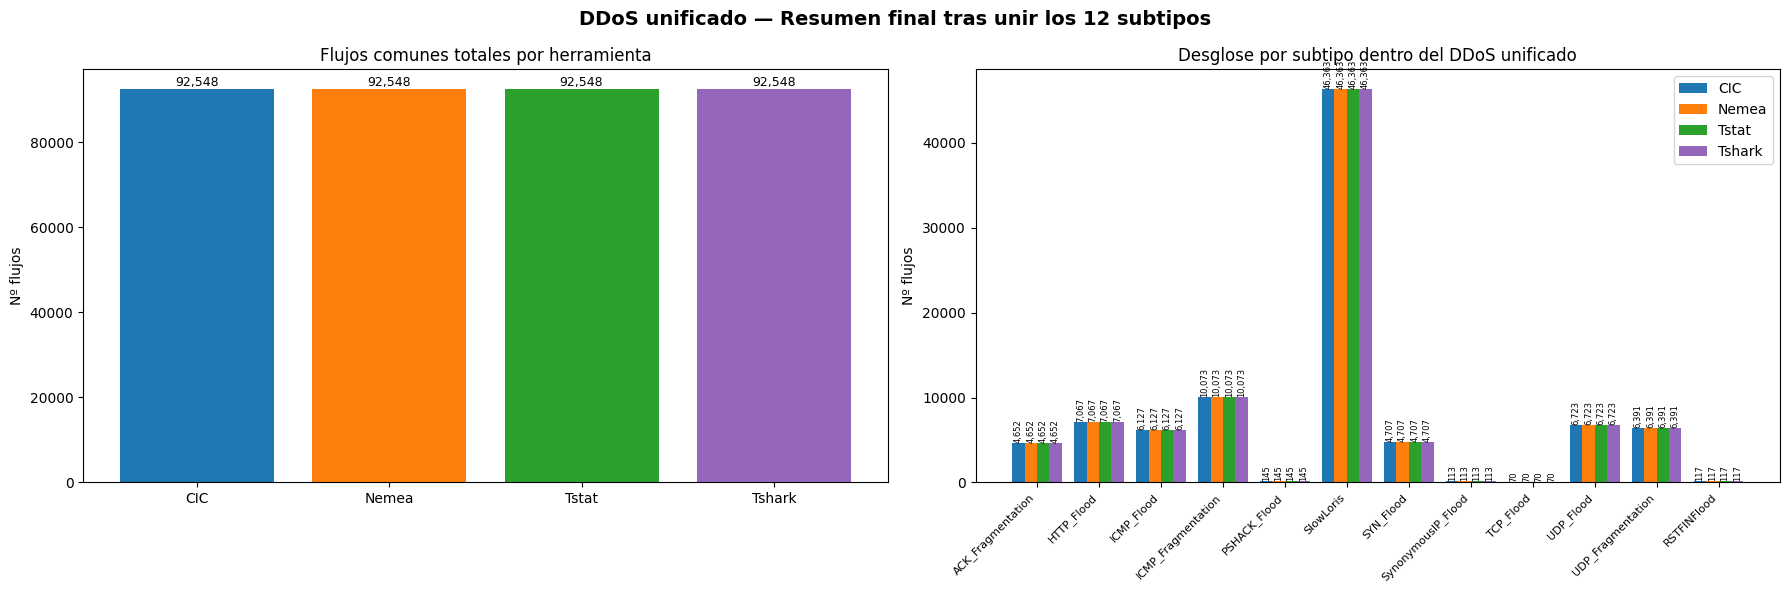


  ✓ Gráfica guardada en: /home/miguel/Escritorio/TFM/TFM_Miguel/MuestrasComunes/DDoS/resumen_DDoS_unificado.png


In [3]:
# ============================================================
# CELDA 7 — GRÁFICA FINAL DDoS UNIFICADO
# (igual que en DoS pero con los 12 subtipos)
# ============================================================
EJECUTAR_GRAFICA = True   # ← True cuando hayas hecho la unión

if not EJECUTAR_GRAFICA:
    print('⏭  Celda 7 saltada.')
else:
    # ... resto del código indentado
    import matplotlib.pyplot as plt
    import numpy as np

    totales_herr = {}
    desglose = {}  # {herr: {sub: n_filas}}

    for herr in HERRAMIENTAS:
        ruta = OUTPUT_DDOS / f'{herr}_comunes.csv'
        if not ruta.exists():
            continue
        df_tmp = pd.read_csv(ruta, low_memory=False, usecols=['subtipo_ddos'])
        totales_herr[herr] = len(df_tmp)
        desglose[herr] = df_tmp['subtipo_ddos'].value_counts().to_dict()
        del df_tmp
        gc.collect()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('DDoS unificado — Resumen final tras unir los 12 subtipos',
                fontsize=14, fontweight='bold')

    # --- Subplot 1: total por herramienta ---
    ax1 = axes[0]
    herrs   = list(totales_herr.keys())
    valores = [totales_herr[h] for h in herrs]
    colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
    bars = ax1.bar(herrs, valores, color=colores[:len(herrs)])
    ax1.set_title('Flujos comunes totales por herramienta')
    ax1.set_ylabel('Nº flujos')
    for b, v in zip(bars, valores):
        ax1.text(b.get_x() + b.get_width()/2, v, f'{v:,}',
                ha='center', va='bottom', fontsize=9)

    # --- Subplot 2: desglose por subtipo (barras agrupadas) ---
    ax2 = axes[1]
    subs = SUBTIPOS
    x = np.arange(len(subs))
    ancho = 0.2
    for i, herr in enumerate(herrs):
        vals = [desglose[herr].get(s, 0) for s in subs]
        barras = ax2.bar(x + i*ancho, vals, ancho, label=herr, color=colores[i])
        for b, v in zip(barras, vals):
            ax2.text(b.get_x() + b.get_width()/2, v, f'{v:,}',
                    ha='center', va='bottom', fontsize=6, rotation=90)
    ax2.set_title('Desglose por subtipo dentro del DDoS unificado')
    ax2.set_xticks(x + ancho*1.5)
    ax2.set_xticklabels(subs, rotation=45, ha='right', fontsize=8)
    ax2.set_ylabel('Nº flujos')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_DDOS / 'resumen_DDoS_unificado.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n  ✓ Gráfica guardada en: {OUTPUT_DDOS / "resumen_DDoS_unificado.png"}')